Complie the mod files:

In [1]:
!nrnivmodl ghchan.mod kca2.mod kdrRL.mod L_Ca.mod mAHP.mod na3rp.mod naps.mod

/home/user/anaconda3/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/home/user/Desktop/Feb2026MouseNEURON
Mod files: "./ghchan.mod" "./kca2.mod" "./kdrRL.mod" "./L_Ca.mod" "./mAHP.mod" "./na3rp.mod" "./naps.mod"

 -> Compiling mod_func.cpp
 => LINKING shared library ./libnrnmech.so
Successfully created x86_64/special


Launch NEURON simulation environment:

In [4]:
from neuron import h,gui
import numpy as np
import matplotlib.pyplot as plt

NEURON: unable to open font "*helvetica-medium-r-normal*--14*", using "fixed"


Load the .hoc files with mouse morphologies:

In [7]:
h.load_file("nrngui.hoc")
h.load_file("1_mosinit_mouse.hoc")

	1 
	1 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	1 


1.0

Select sections for the extracellular mechanism to include the soma and dendritic tree, but not the axon:

In [23]:
sections = h.allsec()
EFsections = []
for sec in sections:
    if sec == h.AH:
        break
    else:
        EFsections.append(sec)

Here you can change the dirrection of the field - sec.y3d for the y axis and sec.x3d for the x axis:

In [25]:
x = []
for sec in EFsections:
    sec_x_values = [sec.y3d(i) for i in range(sec.n3d())]
    sec_x_center = sum(sec_x_values) / len(sec_x_values)
    x.append(sec_x_center)

Choose the EEF magnitude 

In [43]:
field_strength = 0.002

i=0
for sec in EFsections:
    sec.e_extracellular = field_strength * x[i] 
    i = i+1


In [45]:
h.celsius = 22.0

In [ ]:
### Input resistance
iclamp = h.IClamp(h.soma(0.5))
h.dt = 0.01

# Prepare to record time and voltage
t_vec = h.Vector().record(h._ref_t)
v_soma = h.Vector().record(h.soma(0.5)._ref_v)
h.finitialize(-68)
# Run the simulation
while h.t < 500:
    h.fadvance()

t = np.array(t_vec)
vs = np.array(v_soma)
v_rest = np.mean(vs)

iclamp.delay = 300
iclamp.dur = 500
iclamp.amp = 0.02

# Record voltage
t = h.Vector()
v = h.Vector()
t.record(h._ref_t)
v.record(h.soma(0.5)._ref_v)

h.finitialize(-68)
# Run the simulation
while h.t < 900:
    h.fadvance()
# Calculate input resistance

t02 = np.array(t)
v02 = np.array(v)


#set up inject pulse current
h.t = 0  # Reset time
iclamp.amp = 0
h.fcurrent()  # Recalculate currents if needed

iclamp.amp = -0.02

# Record voltage
t = h.Vector()
v = h.Vector()
t.record(h._ref_t)
v.record(h.soma(0.5)._ref_v)

h.finitialize(-68)
# Run the simulation
while h.t < 900:
    h.fadvance()
# Calculate input resistanc

tnegative02 = np.array(t)
vnegative02 = np.array(v)

#set up inject pulse current
h.t = 0  # Reset time
iclamp.amp = 0
h.fcurrent()  # Recalculate currents if needed

iclamp.amp = 0.01

# Record voltage
t = h.Vector()
v = h.Vector()
t.record(h._ref_t)
v.record(h.soma(0.5)._ref_v)

h.finitialize(-68)
# Run the simulation
while h.t < 900:
    h.fadvance()

t01 = np.array(t)
v01 = np.array(v)
# Calculate input resistance

#set up inject pulse current
h.t = 0  # Reset time
iclamp.amp = 0
h.fcurrent()  # Recalculate currents if needed


iclamp.amp = -0.01

# Record voltage
t = h.Vector()
v = h.Vector()
t.record(h._ref_t)
v.record(h.soma(0.5)._ref_v)

h.finitialize(-68)
# Run the simulation
while h.t < 900:
    h.fadvance()
# Calculate input resistanc

tnegative01 = np.array(t)
vnegative01 = np.array(v)


#set up inject pulse current
h.t = 0  # Reset time
iclamp.amp = 0
h.fcurrent()  # Recalculate currents if needed


max_n01 = np.argmin(vnegative01[30000:])
max_n02 = np.argmin(vnegative02[30000:])
max_01 = np.argmax(v01[30000:])
max_02 = np.argmax(v02[30000:])


Voltage = v_rest
Current = [-0.02,-0.01,0.01,0.02]
VoltagePeak = [vnegative02[30000+max_n02]-Voltage,vnegative01[30000+max_n01]-Voltage,v01[30000+max_01]-Voltage,v02[30000+max_02]-Voltage]
VolatgePlateu = [vnegative02[79900]-Voltage,vnegative01[79900]-Voltage,v01[79900]-Voltage,v02[79900]-Voltage]


fig, ax = plt.subplots()
ax.plot(Current, VoltagePeak, c= 'b')
ax.plot(Current, VolatgePlateu, c ='r')
ax.scatter(Current, VoltagePeak, c ='b')
ax.scatter(Current, VolatgePlateu, marker='s', c ='r')


# Move axes to the center
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")

# Hide the other two spines
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")

# Ticks only on bottom and left
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")

plt.show()


from scipy.stats import linregress

# Perform linear regression to get the global slope
slope, intercept, r_value, p_value, std_err = linregress(Current, VoltagePeak)
print(f"Rin peak: {slope}")
print(f"R anf p-values: {r_value, p_value}")
print(f"Gin plateu: {1/slope}")
slope, intercept, r_value, p_value, std_err = linregress(Current, VolatgePlateu)
print(f"Rin plateu: {slope}")
print(f"R anf p-values: {r_value, p_value}")
print(f"Gin plateu: {1/slope}")
plt.figure(figsize=(8, 4))
plt.plot(tnegative01, vnegative01, label="I=-0.01nA")
plt.scatter(tnegative01[30000+max_n01], vnegative01[30000+max_n01], s=20)
plt.scatter(tnegative01[79900], vnegative01[79900], s=20)
plt.plot(tnegative02, vnegative02, label="I=-0.2nA")
plt.scatter(tnegative02[30000+max_n02], vnegative02[30000+max_n02], s=20)
plt.scatter(tnegative02[79900], vnegative02[79900], s=20)
plt.plot(t01, v01, label="I=0.01nA")
plt.scatter(t01[30000+max_01], v01[30000+max_01], s=20)
plt.scatter(t01[79900], v01[79900], s=20)
plt.plot(t02, v02, label="I=0.2nA")
plt.scatter(t02[30000+max_02], v02[30000+max_02], s=20)
plt.scatter(t02[79900], v02[79900], s=20)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.xlim(200,900)
plt.show()

Resting membrane potential: -63.78 mV
Peak of the action potential: 25.05 mV
Action potential height: 88.84 mV
Latency to peak: 4.34 ms


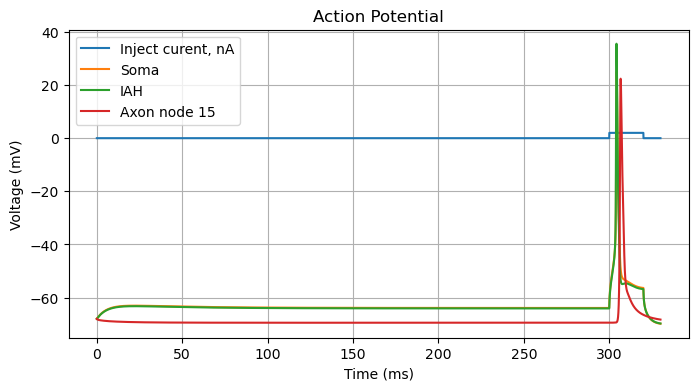

In [16]:
#AP height
iclamp.delay = 300 
iclamp.dur = 20
iclamp.amp = 2

# Prepare to record time and voltage
t_vec = h.Vector().record(h._ref_t)
v_soma = h.Vector().record(h.soma(0.5)._ref_v)
i_soma = h.Vector().record(iclamp._ref_i)
v_ah = h.Vector().record(h.IS(0.5)._ref_v)
v_ax5 = h.Vector().record(h.node[5](0.5)._ref_v)
v_ax15 = h.Vector().record(h.node[15](0.5)._ref_v)
h.finitialize(-68)
# Run the simulation
while h.t < 330:
    h.fadvance()

t = np.array(t_vec)
vs = np.array(v_soma)
i_s = np.array(i_soma)
vah = np.array(v_ah)
vax5 = np.array(v_ax5)
vax15 = np.array(v_ax15)

# Calculate the resting membrane potential (before stimulation)
v_rest = np.mean(vs[t < 300])

# Identify the peak of the action potential
v_peak = np.max(vs)

# Calculate the AP height
ap_height = v_peak - v_rest

latency = 0
for i in range(len(vs)):
    if vs[i] == v_peak:
        latency = t[i] - 300
        break

h.t = 0  # Reset time
iclamp.amp = 0
h.fcurrent()  # Recalculate currents if needed
print(f"Resting membrane potential: {v_rest:.2f} mV")
print(f"Peak of the action potential: {v_peak:.2f} mV")
print(f"Action potential height: {ap_height:.2f} mV")
print(f"Latency to peak: {latency:.2f} ms")
plt.figure(figsize=(8, 4))
plt.plot(t, i_s, label="Inject curent, nA")
plt.plot(t, vs, label="Soma")
plt.plot(t, vah, label="IAH")
#plt.plot(t,vax5, label="Axon node 5")
plt.plot(t,vax15, label = "Axon node 15")
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Action Potential')
plt.legend()
plt.grid()
plt.show()

Rheobase is approximately 0.9600 nA


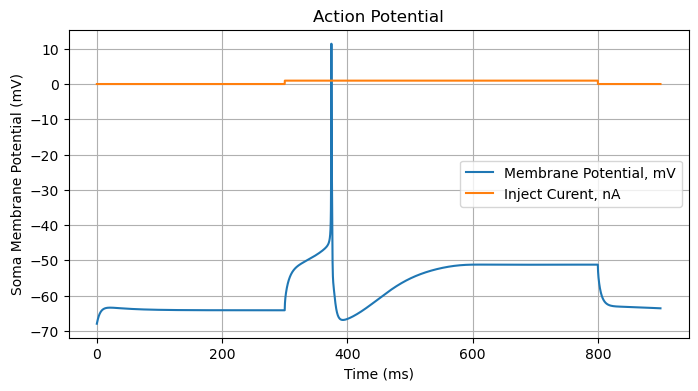

In [69]:
# Rheobase: Start with a small current and gradually increase it
current_amplitudes = np.arange(0.1, 3.0,0.001)
rheobase = None
h.dt = 0.05
iclamp.delay = 300  # Delay in ms before the stimulus starts
iclamp.dur = 500   # Duration of the stimulus in ms (long enough to test rheobase)
for amp in current_amplitudes:

    iclamp.amp = amp

    # Prepare to record time and vo
    t_vec = h.Vector().record(h._ref_t)
    v_vec = h.Vector().record(h.soma(0.5)._ref_v)
    i_vec = h.Vector().record(iclamp._ref_i)

    h.finitialize(-68)
    while h.t < 900:
        h.fadvance()

        # Convert recorded vectors to NumPy arrays
    v_d= np.array(v_vec)
    t_d= np.array(t_vec)
    i_d= np.array(i_vec)
    if np.max(v_d) > -10:
        rheobase = amp
        break
    #set up inject pulse current
    h.t = 0  # Reset time
    iclamp.amp = 0
    h.fcurrent()  # Recalculate currents if needed

if rheobase is not None:
    print(f"Rheobase is approximately {rheobase:.4f} nA")
else:
    print("No spikes were elicited with the tested current range.")


plt.figure(figsize=(8, 4))
plt.plot(t_d, v_d, label="Membrane Potential, mV")
plt.plot(t_d, i_d, label="Inject Curent, nA")
plt.xlabel('Time (ms)')
plt.ylabel('Soma Membrane Potential (mV)')
plt.title('Action Potential')
plt.legend()
plt.grid()
plt.show()


In [19]:
# Set up the inject RAMP IClamp
iclamp.delay = 0    # Start immediately
iclamp.dur = 60000   # Duration of the stimulus in ms, for example

# Simulation parameters
h.dt = 0.025  # Time step in ms
h.tstop = 60000  # Total simulation time in ms

# Time vector
t_vec = np.arange(0, h.tstop, h.dt)

# Triangular ramp parameters
peak_time =30000  # Time at which the ramp peaks (ms)
peak_current = 3  # Peak current amplitude (nA)


# Create a triangular current ramp
current_ramp = np.zeros_like(t_vec)
ramp_up = (peak_current / peak_time) * t_vec[t_vec <= peak_time]
ramp_down = - (peak_current / (h.tstop - peak_time)) * (t_vec[t_vec > peak_time] - peak_time) + peak_current

# Apply the ramp up and ramp down
current_ramp[:len(ramp_up)] = ramp_up
current_ramp[len(ramp_up):] = ramp_down

# Convert the current ramp to an NEURON Vector and play it into IClamp
current_vec = h.Vector(current_ramp)
time_vec = h.Vector(t_vec)
current_vec.play(iclamp._ref_amp, time_vec)


# Prepare to record time, voltage, and current
t_record = h.Vector().record(h._ref_t)
v_record = h.Vector().record(h.soma(0.5)._ref_v)
i_record = h.Vector().record(iclamp._ref_i)
vah_record = h.Vector().record(h.AH(0.5)._ref_v)
vis_record = h.Vector().record(h.IS(0.5)._ref_v)
ik_soma = h.Vector().record(h.soma(0.5)._ref_ik)
ik_AH   = h.Vector().record(h.AH(0.5)._ref_ik)
ipas_soma = h.Vector().record(h.soma(0.5)._ref_i_pas)
ina_soma = h.Vector().record(h.soma(0.5)._ref_ina)
ina_AH   = h.Vector().record(h.AH(0.5)._ref_ina)
ica_soma   = h.Vector().record(h.soma(0.5)._ref_ica)

# Manually set the IClamp amplitude during the simulation
for i, t in enumerate(t_vec):
    iclamp.amp = current_ramp[i]  # Update the IClamp amplitude
    h.fadvance()  # Advance the simulation by one time step

/home/user/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


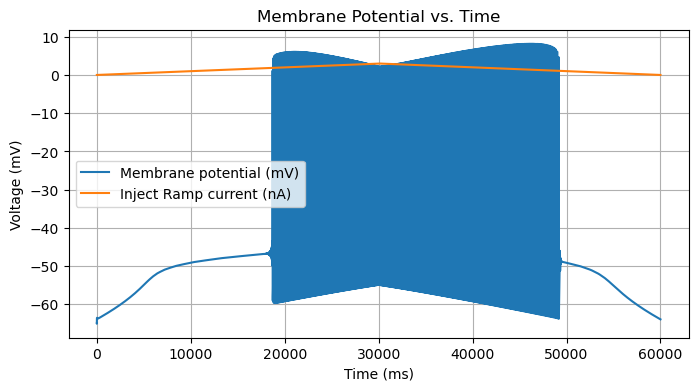

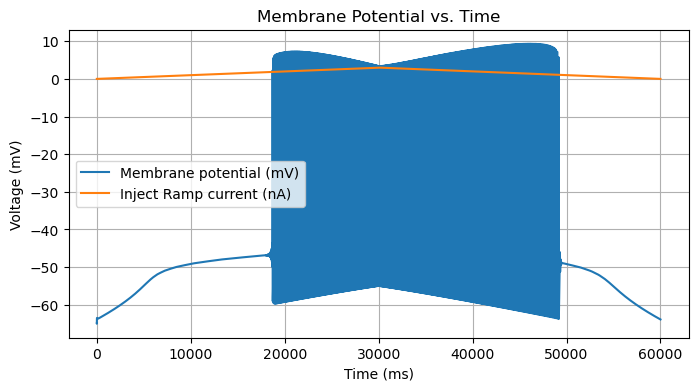

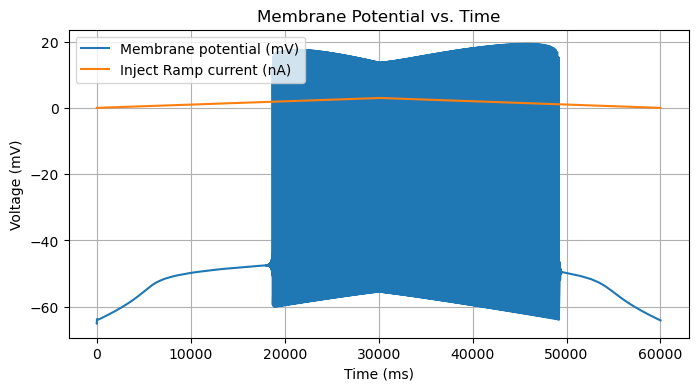

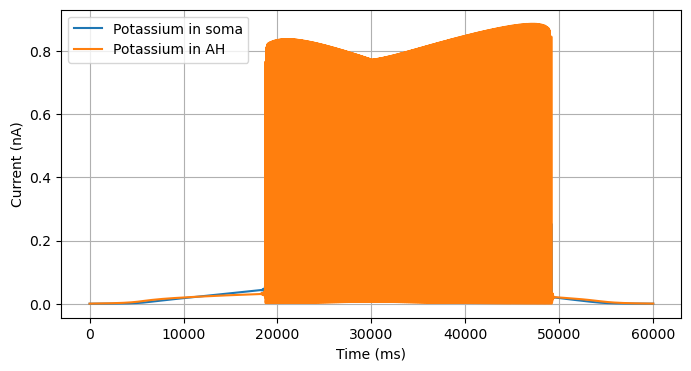

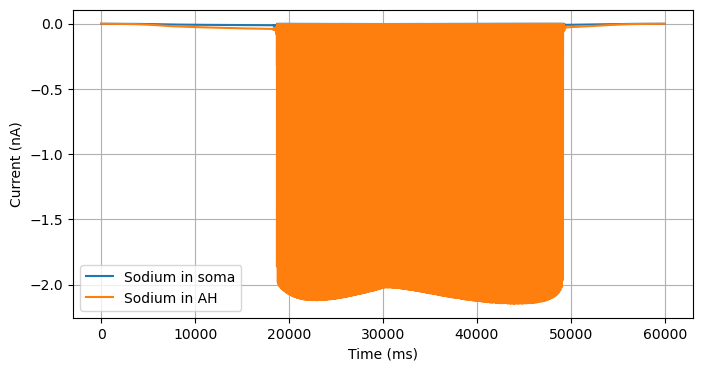

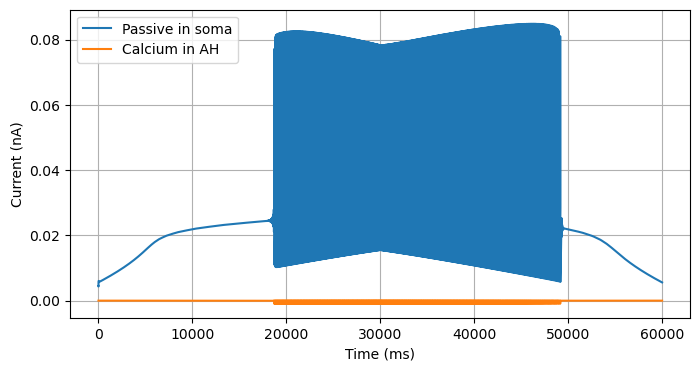

In [20]:
h.finitialize(-65)
# Run the simulation
while h.t < 60000:
    h.fadvance()

t_data = np.array(t_record)
v_data = np.array(v_record)
i_data = np.array(i_record)
vah_data = np.array(vah_record)
vis_data = np.array(vis_record)
ik_s = np.array(ik_soma)
ik_ah = np.array(ik_AH)
ina_s = np.array(ina_soma)
ina_ah = np.array(ina_AH)
ipas_s = np.array(ipas_soma)
ica_s = np.array(ica_soma)
# Plot membrane potential vs. time
plt.figure(figsize=(8, 4))
plt.plot(t_data, v_data, label='Membrane potential (mV)')
plt.plot(t_data, i_data, label='Inject Ramp current (nA)')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Membrane Potential vs. Time')
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(t_data, vah_data, label='Membrane potential (mV)')
plt.plot(t_data, i_data, label='Inject Ramp current (nA)')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Membrane Potential vs. Time')
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(t_data, vis_data, label='Membrane potential (mV)')
plt.plot(t_data, i_data, label='Inject Ramp current (nA)')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Membrane Potential vs. Time')
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(t_data, ik_s, label='Potassium in soma')
plt.plot(t_data, ik_ah, label='Potassium in AH')
plt.xlabel('Time (ms)')
plt.ylabel('Current (nA)')
plt.legend()
plt.grid()
plt.show()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(t_data, ina_s, label='Sodium in soma')
plt.plot(t_data, ina_ah, label='Sodium in AH')
plt.xlabel('Time (ms)')
plt.ylabel('Current (nA)')
plt.legend()
plt.grid()
plt.show()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(t_data, ipas_s, label='Passive in soma')
plt.xlabel('Time (ms)')
plt.ylabel('Current (nA)')
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(t_data, ica_s, label='Calcium in AH')
plt.xlabel('Time (ms)')
plt.ylabel('Current (nA)')
plt.legend()
plt.grid()
plt.show()

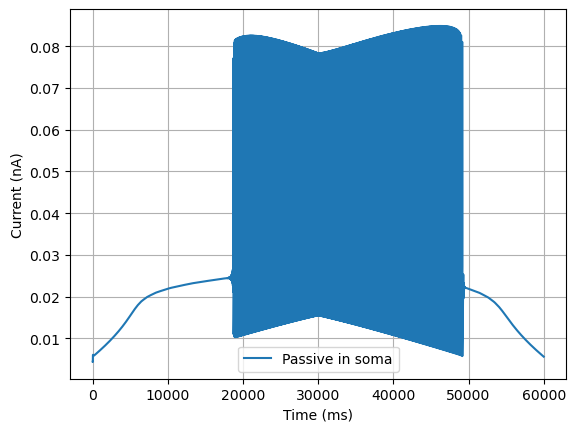

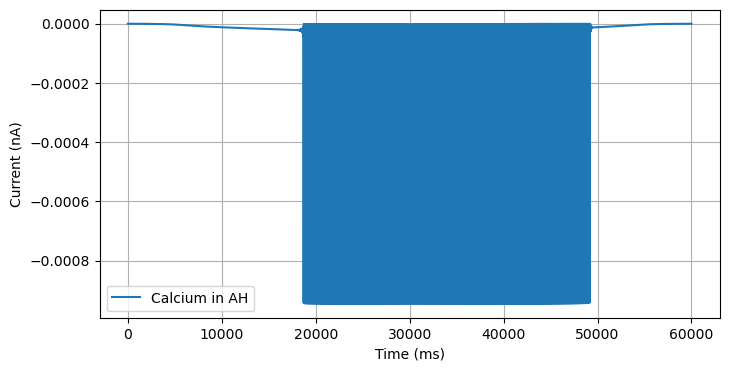

In [23]:
plt.plot(t_data, ipas_s, label='Passive in soma')
plt.xlabel('Time (ms)')
plt.ylabel('Current (nA)')
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8, 4))
plt.plot(t_data, ica_s, label='Calcium in AH')
plt.xlabel('Time (ms)')
plt.ylabel('Current (nA)')
plt.legend()
plt.grid()
plt.show()

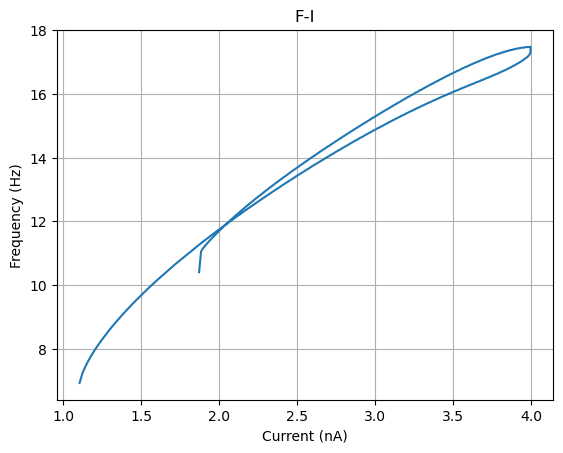

Slope of the global linear fit: 3.141073520055867


In [21]:
from scipy.signal import find_peaks

# Sample data (replace with your actual data)
x = t_data
y = v_data
i = i_data
# Find peaks
peaks, _ = find_peaks(y,height=-30)

# Compute the periods (differences between consecutive peaks)
x_peaks = x[peaks]
periods = np.diff(x_peaks)
i_peaks = i[peaks]
# Compute the frequencies (f = 1 / period)
frequencies = 1000 / periods

# Associate each frequency with the corresponding x-value (midpoint of the interval)
x_midpoints = (x_peaks[:-1] + x_peaks[1:]) / 2
i_midp = (i_peaks[:-1] + i_peaks[1:])/2

# Plot frequency vs x
plt.plot(i_midp, frequencies)
plt.xlabel('Current (nA)')
plt.ylabel('Frequency (Hz)')
plt.title('F-I')
plt.grid()
plt.show()

from scipy.stats import linregress

# Perform linear regression to get the global slope
slope, intercept, r_value, p_value, std_err = linregress(i_midp, frequencies)

# Print the slope
print(f"Slope of the global linear fit: {slope}")

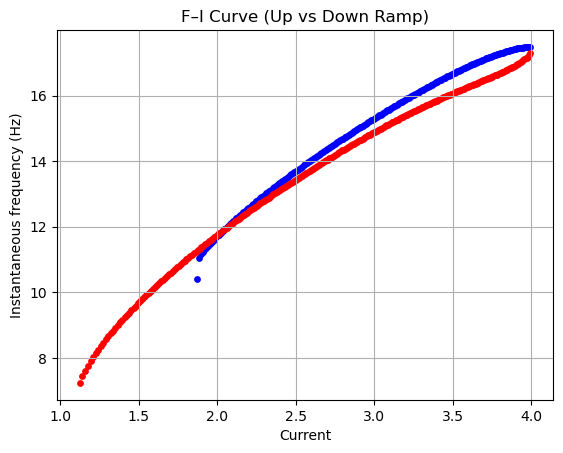

Up-ramp slope: 3.0064917716515955
Up-ramp R^2: 0.9830362836116522
Down-ramp slope: 3.0971385620034657
Down-ramp R^2: 0.9785987140322893


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import linregress

x = t_data        # ms
y = v_data        # mV
i = i_data        # nA (or whatever)

# Estimate dt (ms) assuming uniform sampling
dt = np.median(np.diff(x))

# Spike detection parameters (tune!)
refractory_ms = 1.0
min_distance = int(np.round(refractory_ms / dt))

peaks, props = find_peaks(
    y,
    height=-15,                 # e.g., only peaks above 0 mV (tune!)
    prominence=10,            # mV (tune!)
    distance=min_distance
)

x_peaks = x[peaks]
i_peaks = i[peaks]

# ISIs in ms
isis = np.diff(x_peaks)
frequencies = 1000.0 / isis  # Hz, because ms -> s

# current associated to each ISI
i_mid = 0.5 * (i_peaks[:-1] + i_peaks[1:])

# Detect whether current is increasing or decreasing
di = np.diff(i_mid)

up_mask = di > 0
down_mask = di <= 0

# Because diff shortens by 1, match lengths
i_up = i_mid[:-1][up_mask]
f_up = frequencies[:-1][up_mask]

i_down = i_mid[:-1][down_mask]
f_down = frequencies[:-1][down_mask]

plt.figure()

plt.scatter(i_up, f_up, s=15, c='b')
plt.scatter(i_down, f_down, s=15, c='r')

plt.xlabel('Current')
plt.ylabel('Instantaneous frequency (Hz)')
plt.title('F–I Curve (Up vs Down Ramp)')
plt.grid(True)
plt.show()

# Separate linear fits
if len(i_up) > 1:
    slope_up, intercept_up, r_up, p_up, se_up = linregress(i_up, f_up)
    print("Up-ramp slope:", slope_up)
    print("Up-ramp R^2:", r_up**2)

if len(i_down) > 1:
    slope_down, intercept_down, r_down, p_down, se_down = linregress(i_down, f_down)
    print("Down-ramp slope:", slope_down)
    print("Down-ramp R^2:", r_down**2)
